# Week 2
## 1.Work flow Continue

In [1]:
#2026-5-14
# This block is to import the result and workflow last time.
# RERUN NOTE: Must rerun after regenerating whitened_data.npy. This cell reloads the updated preprocessed signal that drives compression and reconstruction.
import numpy as np
import pandas as pd
from scipy.fftpack import dct, idct
from pathlib import Path
import matplotlib.pyplot as plt
from kilosort.io import load_ops

SAVE_PATH = Path('G:\\ACADEMIC') / '.test_data' / 'ZFM-02370_mini.imec0.ap.short.bin'

n_chan = 385          # channel number
N = 267 # Neuron Number
dtype = 'int16'

# Load the saved Sorting results from the local drive.
results_dir = SAVE_PATH.parent / 'kilosort4'
ops = load_ops(results_dir / 'ops.npy')
camps = pd.read_csv(results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values
contam_pct = pd.read_csv(results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values
chan_map =  np.load(results_dir / 'channel_map.npy')
templates =  np.load(results_dir / 'templates.npy')
chan_best = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best = chan_map[chan_best]
amplitudes = np.load(results_dir / 'amplitudes.npy')
st = np.load(results_dir / 'spike_times.npy')
clu = np.load(results_dir / 'spike_clusters.npy')

fs = ops['fs']
firing_rates = np.unique(clu, return_counts=True)[1] * fs / st.max()
dshift = ops['dshift']

In [2]:
# Get the spike time for each neuron.
unique_clusters = np.unique(clu)

spikes_by_cluster = {}

for cluster_id in unique_clusters:
    times = st[clu == cluster_id] / fs  # fs is the sampling frequency。
    spikes_by_cluster[cluster_id] = times

for cluster_id in unique_clusters[:5]:
    print(f"Cluster {cluster_id}: {len(spikes_by_cluster[cluster_id])} spikes")

Cluster 0: 748 spikes
Cluster 1: 605 spikes
Cluster 2: 1175 spikes
Cluster 3: 1351 spikes
Cluster 4: 1464 spikes


## 2. DCT for original

In [3]:
def compress_signal_dct(signal, keep_ratio=0.1): #signal: input singal, e.g. a part of data in a certain channel.
    
    n = len(signal)
    dct_coeffs = dct(signal, norm='ortho')
    
    cutoff = int(n * keep_ratio) # the number of remaining parameters
    compressed_coeffs = np.zeros(n)
    compressed_coeffs[:cutoff] = dct_coeffs[:cutoff]
    
    # inverse DCT to recover the signal
    reconstructed_signal = idct(compressed_coeffs, norm='ortho')
    
    return reconstructed_signal, compressed_coeffs

In [4]:
np.memmap?

Init signature:
np.memmap(
    filename,
    dtype=<class 'numpy.uint8'>,
    mode='r+',
    offset=0,
    shape=None,
    order='C',
)
Docstring:     
Create a memory-map to an array stored in a *binary* file on disk.

Memory-mapped files are used for accessing small segments of large files
on disk, without reading the entire file into memory.  NumPy's
memmap's are array-like objects.  This differs from Python's ``mmap``
module, which uses file-like objects.

This subclass of ndarray has some unpleasant interactions with
some operations, because it doesn't quite fit properly as a subclass.
An alternative to using this subclass is to create the ``mmap``
object yourself, then create an ndarray with ndarray.__new__ directly,
passing the object created in its 'buffer=' parameter.

This class may at some point be turned into a factory function
which returns a view into an mmap buffer.

Flush the memmap instance to write the changes to the file. Currently there
is no API to close the underl

In [5]:
# Use memmap method to read the portion of data when accessing a specific slice to save memory.
# N=length of (unique_units = np.unique(clu))

file_size_bytes = SAVE_PATH.stat().st_size
total_samples = file_size_bytes // (2 * n_chan) # dtype='int16' 2bytes for each poiny

data = np.memmap(SAVE_PATH, dtype=dtype, mode='r', shape=(total_samples, n_chan))

In [6]:
data

memmap([[-28, -27, -41, ...,  -6,  15,  64],
        [-35, -22, -37, ...,  -6,  23,  64],
        [-20, -15, -21, ...,  -7,  24,  64],
        ...,
        [-11, -30, -17, ...,  -9,  21,  64],
        [-13, -31, -21, ..., -14,  22,  64],
        [-12, -30, -25, ..., -12,  11,  64]],
       shape=(1350000, 385), dtype=int16)

### Data Structure Visualization

| (1,350,000 Rows) | Channel 0 | Channel 1 | Channel 2 | ... | Channel 384 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Sample 0** | -28 | -27 | -41 | ... | 64 |
| **Sample 1** | -35 | -22 | -37 | ... | 64 |
| **Sample 2** | -20 | -15 | -21 | ... | 64 |
| **...** | ... | ... | ... | ... | ... |
| **Sample 1,349,997** | -11 | -30 | -17 | ... | 64 |
| **Sample 1,349,998** | -13 | -31 | -21 | ... | 64 |
| **Sample 1,349,999** | -12 | -30 | -25 | ... | 64 |
| | **$\uparrow$** | **$\uparrow$** | **$\uparrow$** | | **$\uparrow$** |
| | **385 Channels** | **(Columns)** | | | |

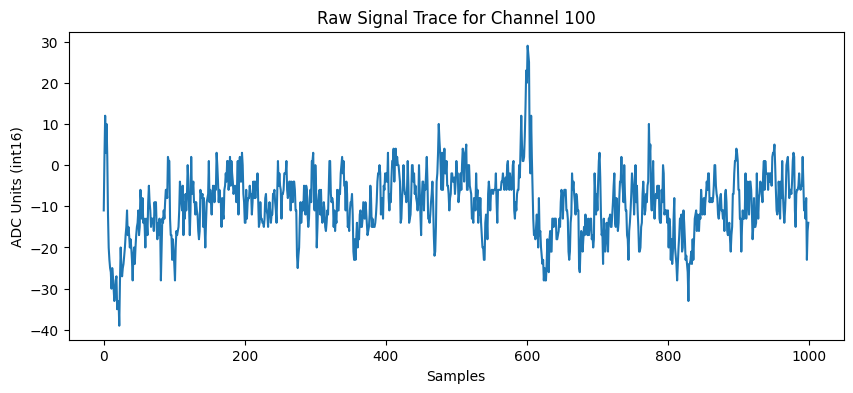

In [7]:
import matplotlib.pyplot as plt

sample_segment = data[0:1000, :] 

plt.figure(figsize=(10, 4))
channel_no=100
plt.plot(sample_segment[:, channel_no])
plt.title(f"Raw Signal Trace for Channel {channel_no}")
plt.xlabel("Samples")
plt.ylabel("ADC Units (int16)")
plt.show()

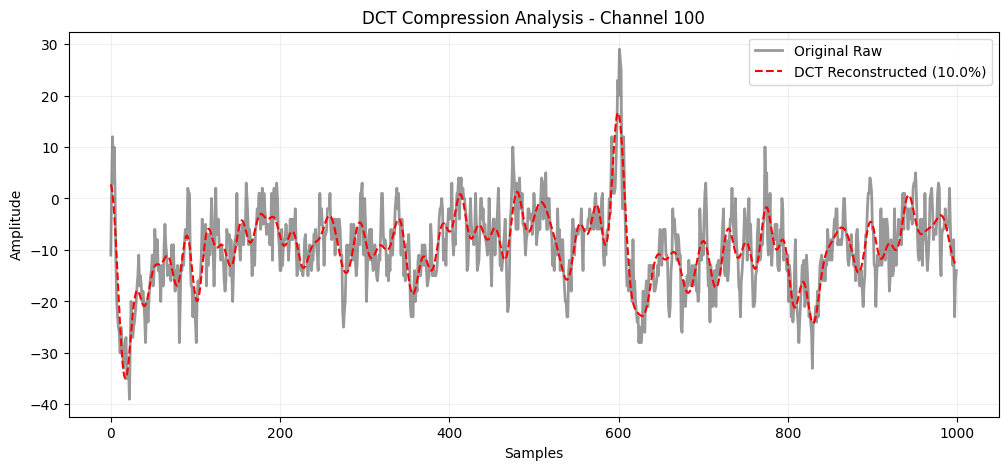

Oringinal sample number: 1000
DCT Sample Number: 100


In [8]:
channel_no=100
raw_signal = data[0:1000, channel_no].astype(np.float32)

keep_ratio = 0.1
reconstructed, coeffs = compress_signal_dct(raw_signal, keep_ratio=keep_ratio)

plt.figure(figsize=(12, 5))

plt.plot(raw_signal, label='Original Raw', color='black', alpha=0.4, linewidth=2)

plt.plot(reconstructed, label=f'DCT Reconstructed ({keep_ratio*100}%)', color='red', linestyle='--')

plt.title(f"DCT Compression Analysis - Channel {channel_no}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Oringinal sample number: {len(raw_signal)}")
print(f"DCT Sample Number: {int(len(raw_signal) * keep_ratio)}")

In [9]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_compression_interactive(channel_no, keep_ratio, sample_range):
    start, end = sample_range
    raw_signal = data[start:end, channel_no].astype(np.float32)
    
    reconstructed, _ = compress_signal_dct(raw_signal, keep_ratio=keep_ratio)
    
    plt.figure(figsize=(12, 5))
    plt.plot(raw_signal, label='Original Raw', color='black', alpha=0.4, linewidth=2)
    plt.plot(reconstructed, label=f'DCT Reconstructed ({keep_ratio*100:.1f}%)', 
             color='red', linestyle='--')
    
    plt.title(f"Interactive DCT Compression - Channel {channel_no}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    
    print(f"Current sample number:  {len(raw_signal)}")
    print(f"Para remaining: {int(len(raw_signal) * keep_ratio)}")
    print(f"Compression Ratio(1/keep_ratio): {1/keep_ratio:.1f}x")

interact(
    plot_compression_interactive, 
    channel_no = widgets.IntText(value=100, description='Channel:'),
    keep_ratio = widgets.FloatSlider(value=0.1, min=0.001, max=1.0, step=0.01, 
                                     description='Keep Ratio:', continuous_update=False),
    sample_range = widgets.IntRangeSlider(value=[0, 1000], min=0, max=20000, step=100,
                                          description='Time Range:', continuous_update=False)
);

widget output removed during UTF-8 notebook repair

In [10]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np

#interact modules initial
cluster_input = widgets.IntText(value=0, description='Cluster ID:')
keep_ratio_slider = widgets.FloatSlider(value=0.1, min=0.00, max=1.00, step=0.01, description='Keep Ratio:', continuous_update=False)
spike_no_slider = widgets.IntSlider(value=0, min=0, max=100, description='Spike No.', continuous_update=False)

def plot_waveforms_stack_compression(cluster_id, keep_ratio, spike_no):
    unit_spike_times = st[clu == cluster_id]
    if len(unit_spike_times) == 0:
        print(f"Cluster {cluster_id} has no spikes.")
        return
    total_spikes = len(unit_spike_times)
    print(f"The total spike number for this neuron is {total_spikes}.")
    spike_no_slider.max = total_spikes - 1
    
    idx = min(spike_no, total_spikes - 1)
    center_sample = int(unit_spike_times[idx])
    
    best_ch = chan_best[cluster_id]
    ch_range = 10 # +-10 channels near the best channel
    start_ch = max(0, best_ch - ch_range)
    end_ch = min(384, best_ch + ch_range)
    channels_to_plot = range(start_ch, end_ch + 1)

    # time window
    window = 60 
    start_t = max(0, center_sample - window)
    end_t = min(data.shape[0], center_sample + window)
    
    plt.figure(figsize=(14, 7))
    
    for ch in channels_to_plot:
        raw_ch = data[start_t:end_t, ch].astype(np.float32)
        
        # optimized
        recon_ch, _ = compress_signal_dct(raw_ch, keep_ratio=keep_ratio)
        
        alpha = 1.0 if ch == best_ch else 0.15
        color = 'red' if ch == best_ch else 'gray'
        lw = 2.5 if ch == best_ch else 0.8
        
        if ch == best_ch:
            plt.plot(raw_ch, color='black', alpha=0.5, label='Original (Best Ch)')
            plt.plot(recon_ch, color='red', linestyle='--', linewidth=lw, label=f'Recon (Best Ch, {keep_ratio*100:.1f}%)')
        else:
            plt.plot(raw_ch, color='gray', alpha=alpha, linewidth=lw)
            plt.plot(recon_ch, color='red', alpha=alpha/2, linestyle='--', linewidth=lw)

    plt.title(f"Neuron No. {cluster_id} (Best Ch: {best_ch}) - Spike #{idx}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.1)
    plt.show()
    
    print(f"Showing channels: {start_ch} to {end_ch}")

interact(plot_waveforms_stack_compression, 
         cluster_id=cluster_input, 
         keep_ratio=keep_ratio_slider, 
         spike_no=spike_no_slider);

widget output removed during UTF-8 notebook repair

| Original | Original |
| :---: | :---: |
| 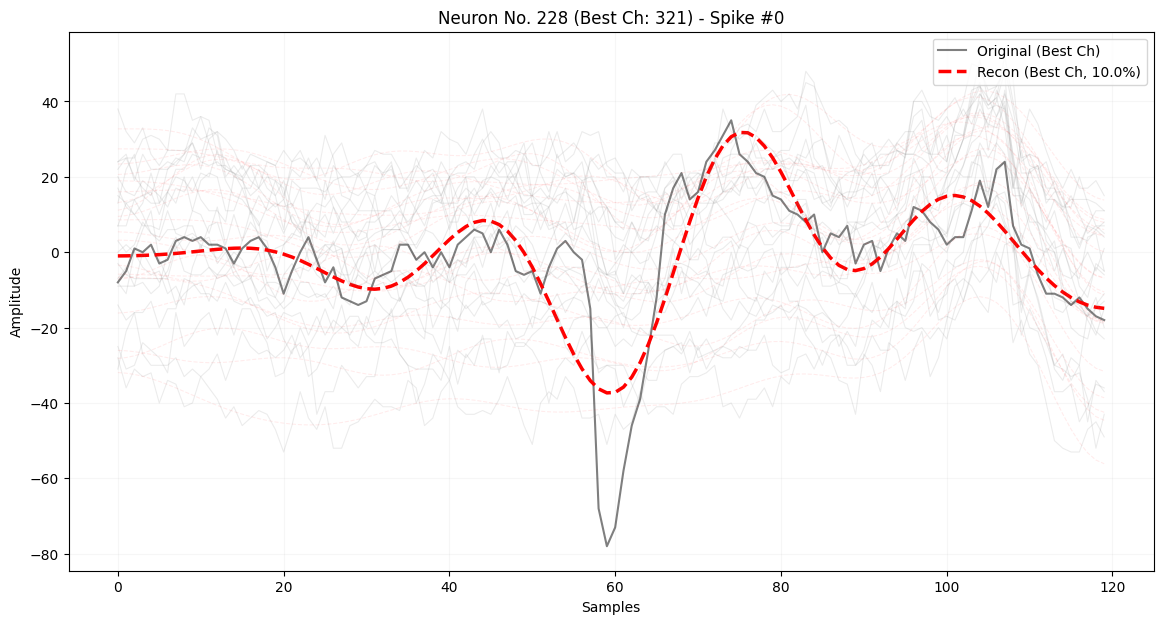 | 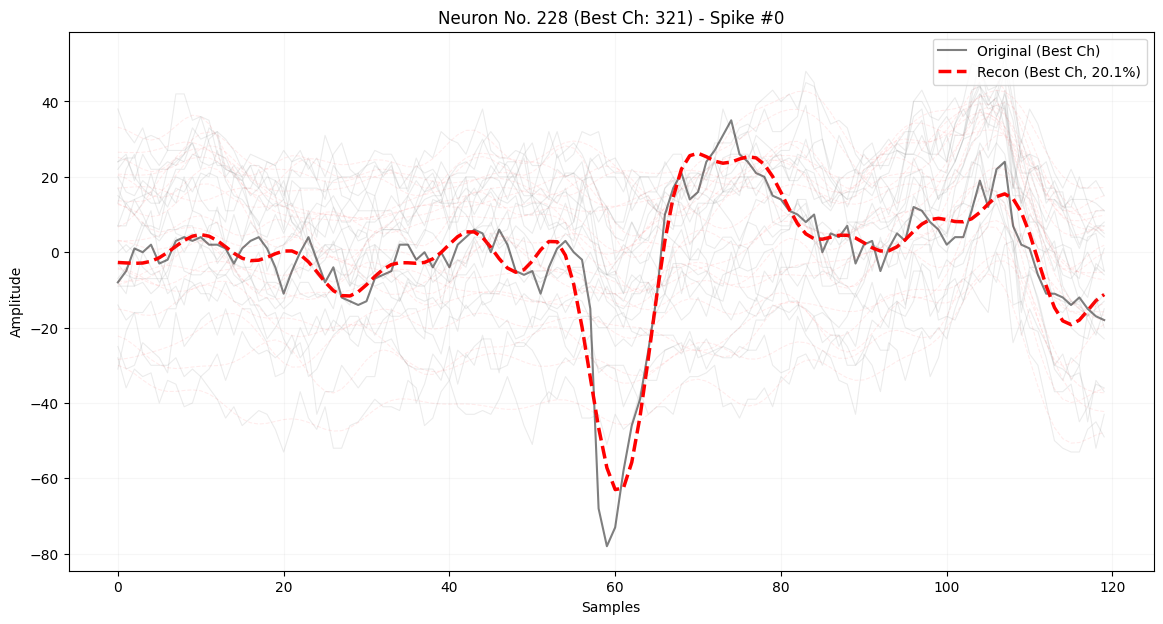 |
| 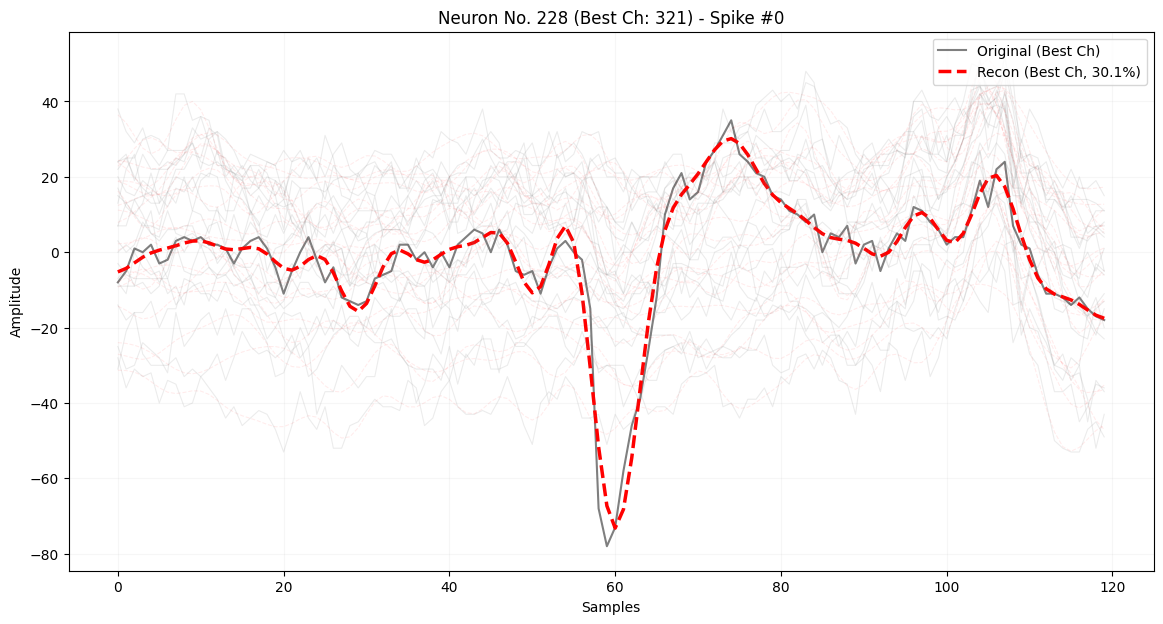 | 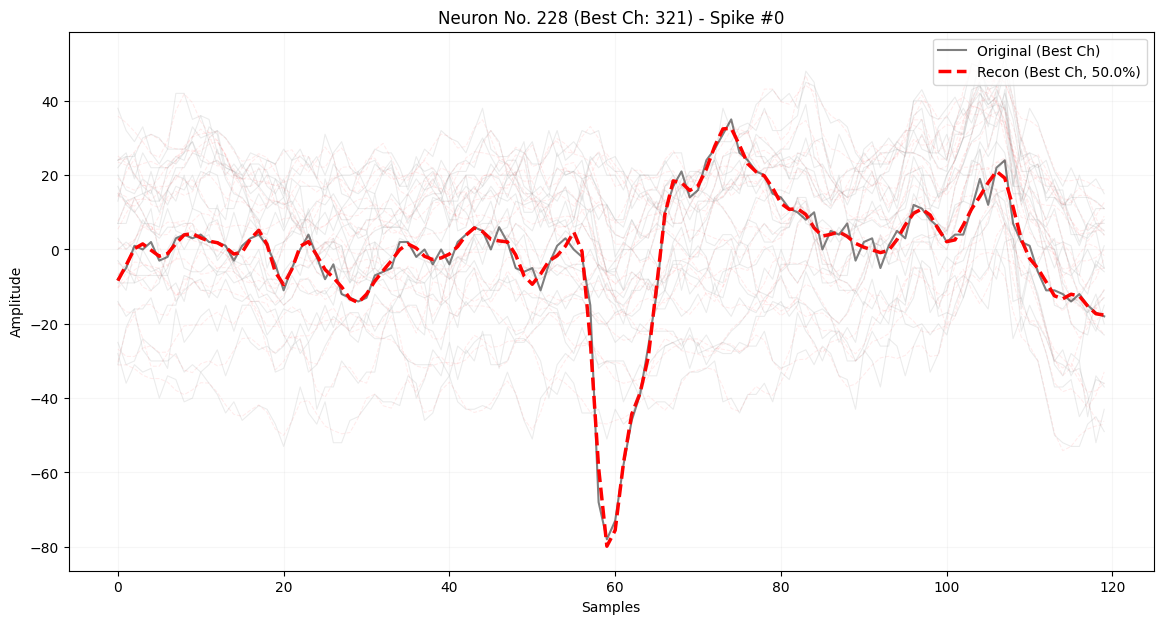 | 
| 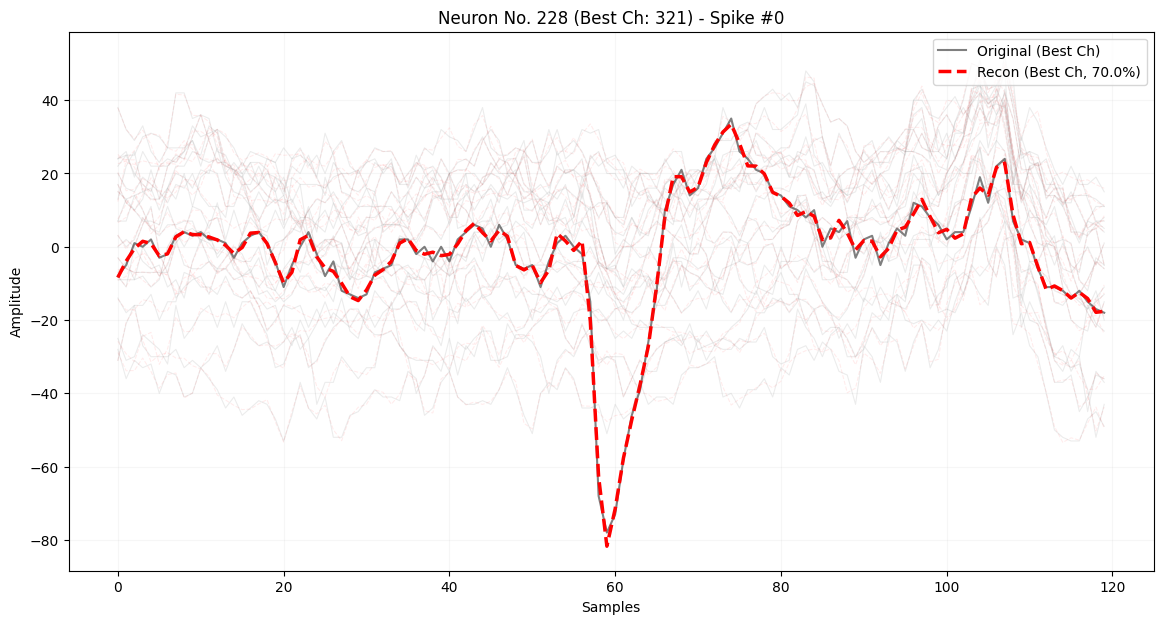 |  |

## 3.Pre-process
### CAR, Bandpass Filtering, Whitening and Detection
> This section now uses **Kilosort built-in preprocessing** directly, instead of custom NumPy / SciPy implementations.
> Specifically, the notebook reuses Kilosort's `BinaryFiltered` pipeline for CAR, temporal high-pass filtering, and spatial whitening, so the upstream `whitened_data.npy` is consistent with Kilosort's own preprocessing behavior.
> The incoming signals contain unwanted local field potentials at the lower frequencies (<100-300 Hz) and high frequency noise (>3-6 kHz) .
> 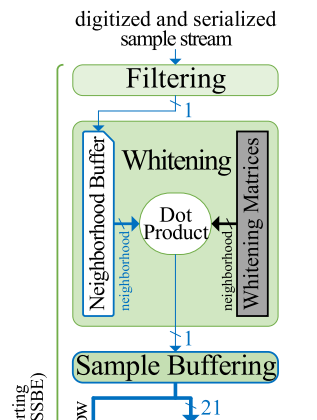

In [11]:
# 2026-5-15
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

In [ ]:
butter?

In [ ]:
sosfiltfilt?

In [14]:
# RERUN NOTE: This cell now switches preprocessing to Kilosort built-ins and must be rerun before any downstream cells that build whitened_data.npy or reconstructed bins.
from kilosort.io import BinaryFiltered
from kilosort.preprocessing import get_highpass_filter, get_whitening_matrix
import torch

def _to_cpu_float_tensor(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.detach().to(device='cpu', dtype=torch.float32)
    return torch.as_tensor(x, dtype=torch.float32, device='cpu')

def prepare_kilosort_preprocessing(raw_path, ops, n_chan_bin, dtype='int16'):
    device = torch.device('cpu')
    probe = ops.get('probe', {})

    chan_map_src = ops.get('chanMap', probe.get('chanMap', np.arange(n_chan_bin, dtype=np.int32)))
    xc_src = ops.get('xc', probe.get('xc', None))
    yc_src = ops.get('yc', probe.get('yc', None))

    chan_map = np.asarray(chan_map_src, dtype=np.int32).reshape(-1)
    if xc_src is None or yc_src is None:
        raise ValueError('Kilosort probe geometry is incomplete; cannot build built-in whitening matrix.')
    xc = np.asarray(xc_src, dtype=np.float32).reshape(-1)
    yc = np.asarray(yc_src, dtype=np.float32).reshape(-1)
    if xc.size < chan_map.size or yc.size < chan_map.size:
        raise ValueError('Probe geometry length is shorter than chanMap.')

    pp = ops.get('preprocessing', {})
    hp_filter = _to_cpu_float_tensor(pp.get('hp_filter'))
    whiten_mat = _to_cpu_float_tensor(pp.get('whiten_mat'))

    if hp_filter is None:
        hp_filter = get_highpass_filter(
            fs=int(ops['fs']),
            cutoff=int(ops.get('highpass_cutoff', 300)),
            device=device,
        )

    if whiten_mat is None:
        whitening_probe = BinaryFiltered(
            filename=raw_path,
            n_chan_bin=n_chan_bin,
            fs=int(ops['fs']),
            NT=int(ops.get('batch_size', 60000)),
            nt=int(ops.get('nt', 61)),
            nt0min=int(ops.get('nt0min', 20)),
            chan_map=chan_map,
            hp_filter=hp_filter,
            whiten_mat=None,
            device=device,
            do_CAR=True,
            dtype=dtype,
        )
        whiten_mat = get_whitening_matrix(
            whitening_probe,
            xc[:chan_map.size],
            yc[:chan_map.size],
            nskip=int(ops.get('nskip', 25)),
            nrange=int(ops.get('whitening_range', min(32, chan_map.size))),
        ).detach().to(device='cpu', dtype=torch.float32)

    return {
        'device': device,
        'chan_map': chan_map,
        'hp_filter': hp_filter,
        'whiten_mat': whiten_mat,
    }

def materialize_binaryfiltered_output(raw_path, n_chan_bin, ops, preprocess_state, hp_filter=None, whiten_mat=None, do_CAR=True, dtype='int16'):
    bfile = BinaryFiltered(
        filename=raw_path,
        n_chan_bin=n_chan_bin,
        fs=int(ops['fs']),
        NT=int(ops.get('batch_size', 60000)),
        nt=int(ops.get('nt', 61)),
        nt0min=int(ops.get('nt0min', 20)),
        chan_map=preprocess_state['chan_map'],
        hp_filter=hp_filter,
        whiten_mat=whiten_mat,
        device=preprocess_state['device'],
        do_CAR=do_CAR,
        dtype=dtype,
    )
    return bfile[:, :].detach().cpu().numpy().T.astype(np.float32, copy=False)


The whitening step below is no longer a custom ZCA implementation. It now uses Kilosort's own local spatial whitening (`get_whitening_matrix` + `BinaryFiltered`), so the whitening matrix matches Kilosort preprocessing logic as closely as possible on this machine.


In [15]:
# Kilosort built-in whitening is prepared in the helper above.


In the classic Quiroga method, the spike detection threshold for each channel is automatically calculated using the following formulas:

$$\text{Threshold} = k \cdot \sigma_n$$

$$\sigma_n = \text{median} \left( \frac{|x(t)|}{0.6745} \right)$$

### Parameter Descriptions:
*   $x(t)$: The filtered (and whitened) continuous single-channel voltage signal.
*   $k$: The threshold coefficient (typically set to a constant value between $4$ and $5$; in the code, `thresh_num_sigma=4.0` is used).
*   $\sigma_n$: The automatically estimated standard deviation of the pure background noise.
*   $0.6745$: A mathematical constant derived from the Gaussian (normal) distribution ($1 / \Phi^{-1}(0.75) \approx 0.6745$), used to map the median of the absolute values to the true standard deviation of the background noise.

In [16]:
def detect_spikes(whitened_data, channel_no, thresh_num_sigma=4.0): # thresh_num_sigma=4.5 is too large.
    signal = whitened_data[:, channel_no]
    
    sigma_n = np.median(np.abs(signal)) / 0.6745
    threshold = thresh_num_sigma * sigma_n
    
    # Spike typically jumps downwards (negatively).
    # Find the point when falling below the negative threshold
    spike_indices = np.where(signal < -threshold)[0] #[0] converts tuple to array.
    
    # For real neurons, the electrical pathways close within 1 ms after a discharge, making it absolutely physically impossible for them to spike again.
    clean_spike_indices = []
    if len(spike_indices) > 0:
        last_idx = spike_indices[0] # Set the first one as reference, clean the repeated ones.
        clean_spike_indices.append(last_idx)
        for idx in spike_indices[1:]:
            if idx - last_idx > 30:  # 30 samples ?1ms
                clean_spike_indices.append(idx)
            last_idx = idx
            
    return np.array(clean_spike_indices), -threshold

In [17]:
# RERUN NOTE: Must rerun after the preprocessing change. This cell regenerates the in-memory preprocessed signal used by the rest of the notebook.
# Pre-process workflow for a certain neuron using Kilosort built-ins.
preprocess_state = prepare_kilosort_preprocessing(SAVE_PATH, ops, n_chan, dtype=dtype)

car_data = materialize_binaryfiltered_output(
    SAVE_PATH,
    n_chan,
    ops,
    preprocess_state,
    hp_filter=None,
    whiten_mat=None,
    do_CAR=True,
    dtype=dtype,
)

filtered_data = materialize_binaryfiltered_output(
    SAVE_PATH,
    n_chan,
    ops,
    preprocess_state,
    hp_filter=preprocess_state['hp_filter'],
    whiten_mat=None,
    do_CAR=True,
    dtype=dtype,
)

whitened_data = materialize_binaryfiltered_output(
    SAVE_PATH,
    n_chan,
    ops,
    preprocess_state,
    hp_filter=preprocess_state['hp_filter'],
    whiten_mat=preprocess_state['whiten_mat'],
    do_CAR=True,
    dtype=dtype,
)

channel_to_test = 100
if channel_to_test >= whitened_data.shape[1]:
    raise ValueError(f'channel_to_test={channel_to_test} exceeds processed channel count={whitened_data.shape[1]}.')
raw_channel_to_test = int(preprocess_state['chan_map'][channel_to_test])

spike_locs, thresh_val = detect_spikes(whitened_data, channel_no=channel_to_test)

print(f'For processed channel no. {channel_to_test}, got {len(spike_locs)} spike after Kilosort built-in preprocessing.')
print(f'Processed channel {channel_to_test} maps to raw channel {raw_channel_to_test}.')


For processed channel no. 100, got 410 spike after Kilosort built-in preprocessing.
Processed channel 100 maps to raw channel 100.


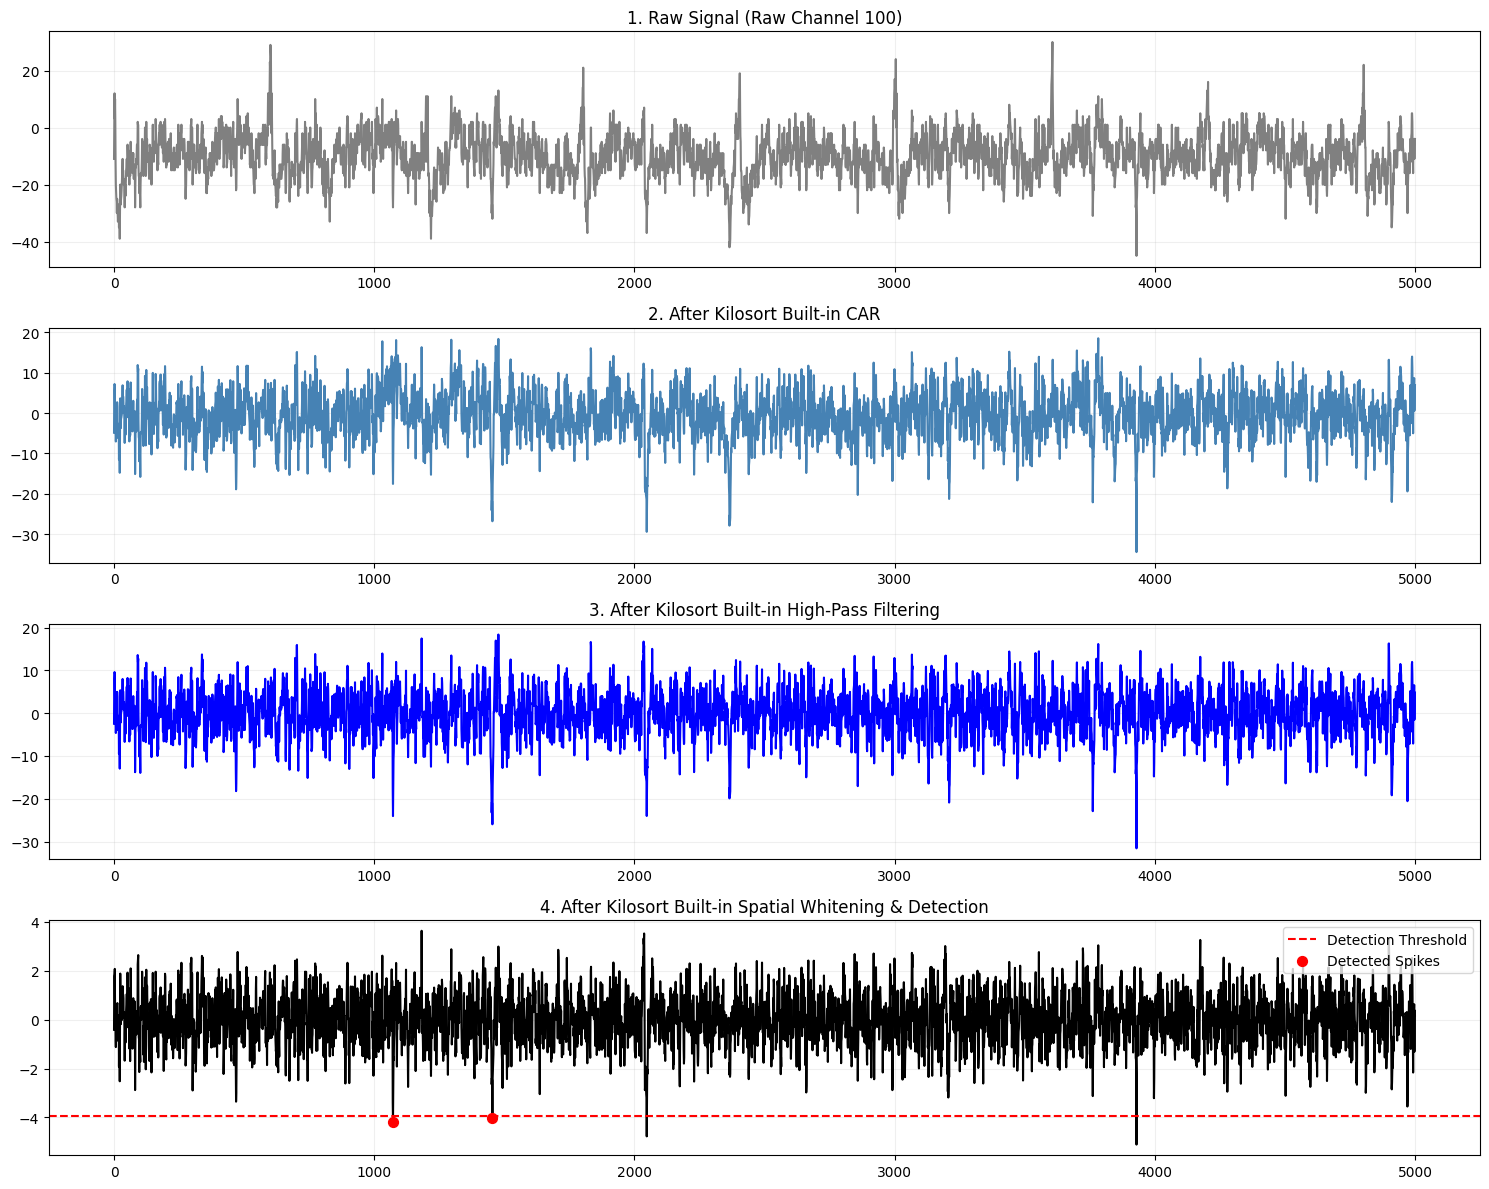

In [18]:
# get first 5000 as an example.
view_win = slice(0, 5000)

plt.figure(figsize=(15, 12))

# original
plt.subplot(4, 1, 1)
plt.plot(data[view_win, raw_channel_to_test], color='gray')
plt.title(f"1. Raw Signal (Raw Channel {raw_channel_to_test})")
plt.grid(True, alpha=0.2)

# after CAR
plt.subplot(4, 1, 2)
plt.plot(car_data[view_win, channel_to_test], color='steelblue')
plt.title("2. After Kilosort Built-in CAR")
plt.grid(True, alpha=0.2)

# after filter
plt.subplot(4, 1, 3)
plt.plot(filtered_data[view_win, channel_to_test], color='blue')
plt.title("3. After Kilosort Built-in High-Pass Filtering")
plt.grid(True, alpha=0.2)

# after whitening and spike detection
plt.subplot(4, 1, 4)
plt.plot(whitened_data[view_win, channel_to_test], color='black')
# threshold
plt.axhline(y=thresh_val, color='red', linestyle='--', label=f'Detection Threshold')
# detected spike
visible_spikes = spike_locs[spike_locs < 2000]
if len(visible_spikes) > 0:
    plt.scatter(visible_spikes, whitened_data[visible_spikes, channel_to_test], color='red', s=50, zorder=5, label='Detected Spikes')

plt.title("4. After Kilosort Built-in Spatial Whitening & Detection")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [19]:
import numpy as np
from scipy.fftpack import dct, idct

window_size = 100  # for each Spike
keep_ratio = 0.1   
n_keep = int(window_size * keep_ratio)

compressed_snippets = []
for loc in spike_locs:
    
    start = max(0, loc - window_size // 2)
    end = min(whitened_data.shape[0], start + window_size)
    snippet = whitened_data[start:end, channel_to_test].astype(np.float32)
    
    # DCT
    dct_coeffs = dct(snippet, norm='ortho')
    
    # keep first n paras
    compressed_coeffs = np.zeros_like(dct_coeffs)
    compressed_coeffs[:n_keep] = dct_coeffs[:n_keep]
    
    recon = idct(compressed_coeffs, norm='ortho')
    compressed_snippets.append({
        'original': snippet,
        'reconstructed': recon,
        'loc': loc
    })

print(f"Compressed with {len(compressed_snippets)} Spikes in total.")

Compressed with 410 Spikes in total.


In [20]:
spike_slider = widgets.IntSlider(min=0, max=len(compressed_snippets)-1, step=1, description='Spike ID:', continuous_update=False)
spike_input = widgets.IntText(description='Spike ID(Input):', layout=widgets.Layout(width='150px'))
ratio_slider = widgets.FloatSlider(value=0.1, min=0.00, max=1.0, step=0.01, description='Keep Ratio:', continuous_update=False)
neuron_input = widgets.IntText(value=100, description='Neuron No:', layout=widgets.Layout(width='150px'))

widgets.jslink((spike_slider, 'value'), (spike_input, 'value'))

def plot_compressed_explorer(spike_idx, keep_ratio, neuron_no):
    thresh_num_sigma = 4.0
    if not compressed_snippets:
        print("Error: No snippets found.")
        return
    
    data_item = compressed_snippets[spike_idx]
    original = data_item['original']
    
    n_keep = int(len(original) * keep_ratio)
    dct_coeffs = dct(original, norm='ortho')
    compressed_coeffs = np.zeros_like(dct_coeffs)
    compressed_coeffs[:n_keep] = dct_coeffs[:n_keep]
    reconstructed = idct(compressed_coeffs, norm='ortho')
    
    plt.figure(figsize=(12, 5))
    plt.plot(original, color='black', alpha=0.3, label=f'Whitened (Ch {neuron_no})')
    plt.plot(reconstructed, color='red', linewidth=2, label=f'DCT Recon ({keep_ratio*100:.1f}%)')
    
    plt.title(f"Neuron {neuron_no} - Spike #{spike_idx} - Ratio: {keep_ratio}")
    plt.xlabel("Samples")
    plt.ylabel("Normalized Amp ($\sigma$)")
    plt.axhline(y=-thresh_num_sigma, color='blue', linestyle='--', alpha=0.2, label='Threshold')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.1)
    plt.ylim(-8, 6)
    plt.show()

ui = widgets.VBox([
    widgets.HBox([spike_slider, spike_input]),
    widgets.HBox([ratio_slider, neuron_input])
])

out = widgets.interactive_output(plot_compressed_explorer, {
    'spike_idx': spike_slider, 
    'keep_ratio': ratio_slider, 
    'neuron_no': neuron_input
})

display(ui, out)

widget output removed during UTF-8 notebook repair

Output()

| After pre-process | After pre-process|
| --- | --- |
| 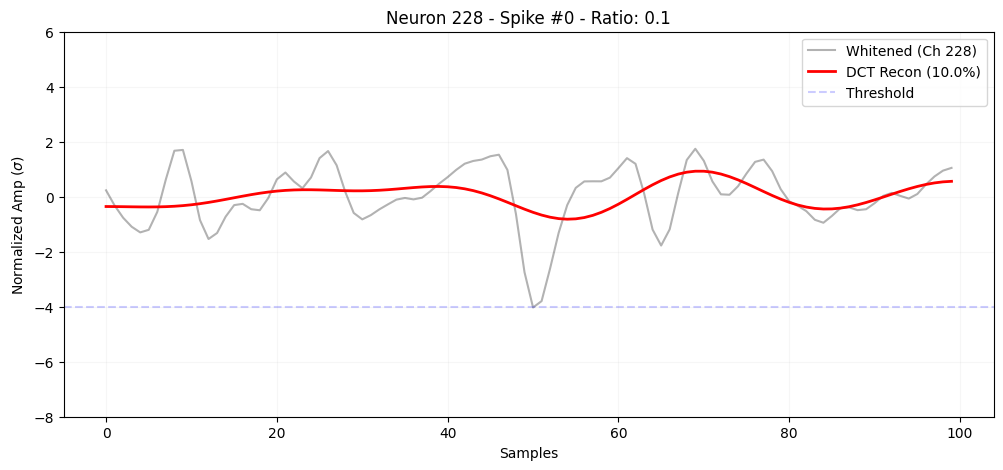 |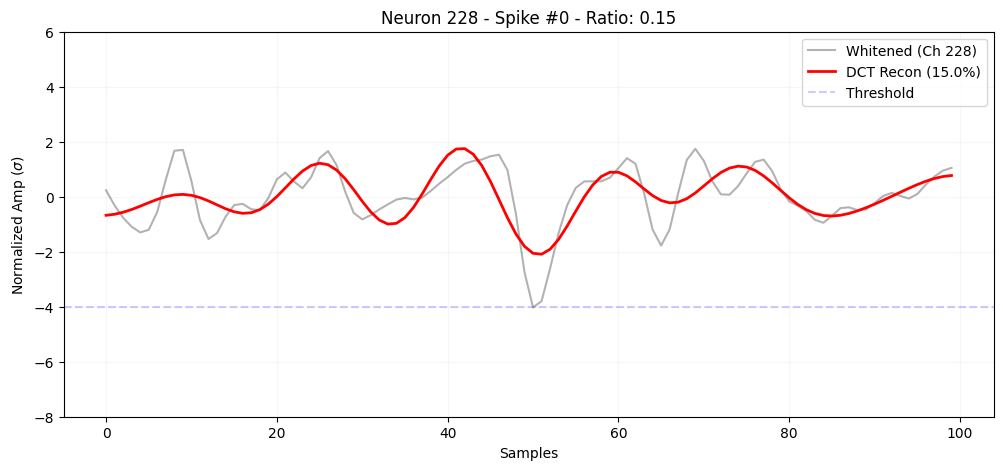|
|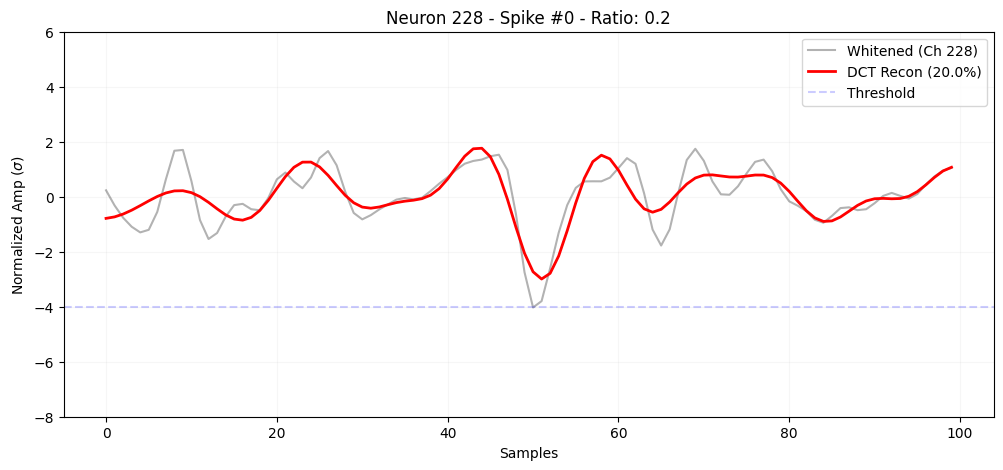 | 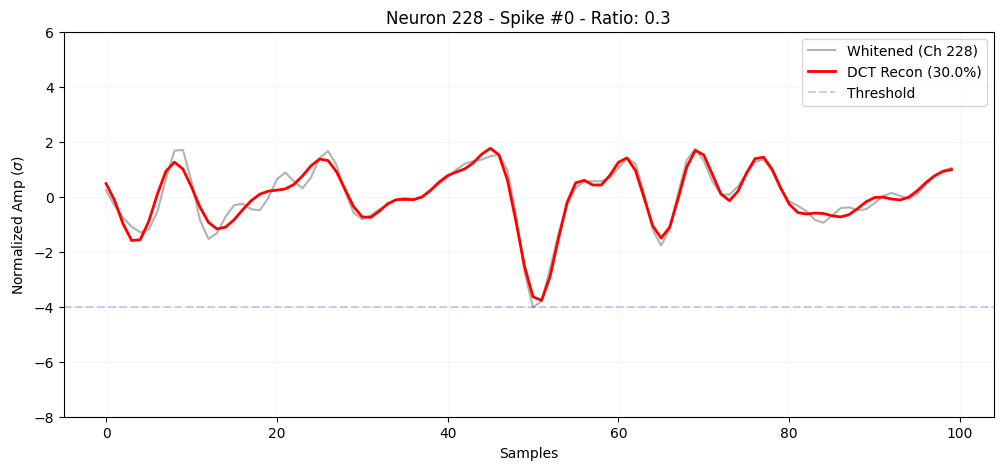 |

In [21]:
# RERUN NOTE: Must rerun after the preprocessing change. This cell overwrites whitened_data.npy, which invalidates old compression / reconstruction outputs.
# Save the Kilosort-built-in CAR -> filtered -> whitened data for downstream compression / reconstruction.
np.save('whitened_data.npy', whitened_data)
print("Saved.")
# whitened_data = np.load('whitened_data.npy')
# print(f"{whitened_data.shape},{whitened_data.dtype}")


Saved.


## 4. Compare Sorting Performance Under Compression (Whitened -> Compress -> Decompress -> Kilosort4)

This section enforces:
1. Sort **decompressed** data (not directly compressed coefficients).
2. Compare against sorting on full CAR-corrected, filtered, and whitened data.
3. Evaluate keep_ratio = 0.2 and 0.1.
4. Keep detection templates configuration consistent with baseline (`templates_from_data=False`).


In [22]:
import numpy as np
from pathlib import Path
from scipy.fftpack import dct, idct
from scipy.optimize import linear_sum_assignment

from kilosort import run_kilosort

# ---- Load inputs from previous sections ----
print("Loading inputs from previous sections")
whitened_data = np.load('whitened_data.npy')
baseline_res = np.load('baseline_results.npy', allow_pickle=True).item()

print(f'whitened_data: {whitened_data.shape}, dtype={whitened_data.dtype}')
print(f'baseline clusters: {len(np.unique(baseline_res["clu"]))}')

# Align data channels to baseline probe channels (baseline uses 383 valid channels from 385-bin file).
if 'probe' in baseline_res['ops'] and 'chanMap' in baseline_res['ops']['probe']:
    valid_chan_map = np.asarray(baseline_res['ops']['probe']['chanMap']).reshape(-1).astype(np.int32)
else:
    valid_chan_map = np.arange(len(np.asarray(baseline_res['xc']).reshape(-1)), dtype=np.int32)

if whitened_data.shape[1] > len(valid_chan_map):
    whitened_data = whitened_data[:, valid_chan_map]

print(f'aligned whitened_data: {whitened_data.shape}, valid channels: {len(valid_chan_map)}')


Loading inputs from previous sections
whitened_data: (1350000, 383), dtype=float32
baseline clusters: 267
aligned whitened_data: (1350000, 383), valid channels: 383


In [23]:
def build_probe_from_baseline(baseline_res, n_chan):
    p0 = baseline_res['ops'].get('probe', {})
    chan_map = np.asarray(p0.get('chanMap', np.arange(n_chan))).reshape(-1).astype(np.int32)
    xc = np.asarray(p0.get('xc', baseline_res['xc'])).reshape(-1)
    yc = np.asarray(p0.get('yc', baseline_res['yc'])).reshape(-1)
    kc = np.asarray(p0.get('kcoords', np.zeros_like(chan_map))).reshape(-1)

    # use common valid length and then force to n_chan expected by current data
    m = min(len(chan_map), len(xc), len(yc), len(kc), n_chan)
    if m < 1:
        raise ValueError('Invalid probe geometry after alignment.')

    return {
        'chanMap': np.arange(m, dtype=np.int32),
        'xc': xc[:m].astype(np.float32, copy=False),
        'yc': yc[:m].astype(np.float32, copy=False),
        'kcoords': kc[:m].astype(np.int32, copy=False),
    }

def build_fixed_template_settings(baseline_res, n_chan, fs=30000):
    # Keep template-related behavior consistent with baseline sort.
    s = {
        'n_chan_bin': int(n_chan),
        'fs': fs,
        'nt': 61,
        'nt0min': baseline_res['ops'].get('nt0min', 20),
        'batch_size': baseline_res['ops'].get('batch_size', 20000),
        'nskip': baseline_res['ops'].get('nskip', 25),
        # NOTE: in this kilosort version, 0 causes empty neighborhood in whitening_local
        'whitening_range': baseline_res['ops'].get('whitening_range', min(32, n_chan)),
        'nearest_chans': baseline_res['ops'].get('nearest_chans', min(32, n_chan)),
        'n_pcs': baseline_res['ops'].get('n_pcs', 6),
        'Th_universal': baseline_res['ops'].get('Th_universal', 9),
        'Th_learned': baseline_res['ops'].get('Th_learned', 6),
        'duplicate_spike_ms': baseline_res['ops'].get('duplicate_spike_ms', 0.25),
        'max_channel_distance': baseline_res['ops'].get('max_channel_distance', 100),
        # Critical for template consistency requirement
        'templates_from_data': False,
    }

    # If baseline has geometry constraints, keep them aligned.
    for k in ['d_min', 'd_max', 'dmin', 'dminx', 'min_template_size', 'template_sizes']:
        if k in baseline_res['ops']:
            s[k] = baseline_res['ops'][k]

    wr = s.get('whitening_range', None)
    try:
        wr = int(wr)
    except Exception:
        wr = min(32, n_chan)
    wr = max(1, min(wr, n_chan))
    s['whitening_range'] = wr

    return s

def compress_whitened_to_coeff(whitened_data, keep_ratio, out_prefix):
    n_samples, n_chan = whitened_data.shape
    n_keep = max(1, int(n_samples * keep_ratio))
    coeff_path = Path(f'{out_prefix}_ratio_{keep_ratio:.2f}_coeff.npy')

    coeff_mm = np.memmap(coeff_path, dtype='float32', mode='w+', shape=(n_keep, n_chan))
    for ch in range(n_chan):
        c = dct(whitened_data[:, ch], norm='ortho')
        coeff_mm[:, ch] = c[:n_keep].astype('float32')
    coeff_mm.flush()
    del coeff_mm

    return coeff_path, n_keep

def decompress_coeff_to_bin(coeff_path, n_samples, n_chan, n_keep, out_bin):
    coeff_mm = np.memmap(coeff_path, dtype='float32', mode='r', shape=(n_keep, n_chan))
    recon_mm = np.memmap(out_bin, dtype='float32', mode='w+', shape=(n_samples, n_chan))

    for ch in range(n_chan):
        c_full = np.zeros(n_samples, dtype='float32')
        c_full[:n_keep] = coeff_mm[:, ch]
        recon_mm[:, ch] = idct(c_full, norm='ortho').astype('float32')

    recon_mm.flush()
    del coeff_mm
    del recon_mm
    return Path(out_bin)

def run_kilosort_experiment(binary_path, probe, settings, results_dir):
    settings = dict(settings)
    n_chan = int(settings['n_chan_bin'])

    wr = settings.get('whitening_range', 32)
    try:
        wr = int(wr)
    except Exception:
        wr = 32
    settings['whitening_range'] = max(1, min(wr, n_chan))

    probe = dict(probe)
    probe['chanMap'] = np.asarray(probe['chanMap']).reshape(-1)[:n_chan].astype(np.int32, copy=False)
    probe['xc'] = np.asarray(probe['xc']).reshape(-1)[:n_chan].astype(np.float32, copy=False)
    probe['yc'] = np.asarray(probe['yc']).reshape(-1)[:n_chan].astype(np.float32, copy=False)
    probe['kcoords'] = np.asarray(probe['kcoords']).reshape(-1)[:n_chan].astype(np.int32, copy=False)

    print(f"[DEBUG] n_chan_bin={settings['n_chan_bin']}, whitening_range={settings['whitening_range']}")
    print(f"[DEBUG] probe lens: chanMap={len(probe['chanMap'])}, xc={len(probe['xc'])}, yc={len(probe['yc'])}")

    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    out = run_kilosort(
        settings=settings,
        probe=probe,
        filename=binary_path,
        results_dir=results_dir,
        do_CAR=False,
        data_dtype='float32'
    )

    # Kilosort API compatibility: some versions return 8 items, newer ones return 9 (with kept_spikes).
    if len(out) == 9:
        ops, st, clu, tF, Wall, similar_templates, is_ref, est_contam_rate, kept_spikes = out
    elif len(out) == 8:
        ops, st, clu, tF, Wall, similar_templates, is_ref, est_contam_rate = out
        kept_spikes = None
    else:
        raise ValueError(f'Unexpected run_kilosort return length: {len(out)}')

    result = {
        'ops': ops,
        'st': st,
        'clu': clu,
        'tF': tF,
        'Wall': Wall,
        'similar_templates': similar_templates,
        'is_ref': is_ref,
        'est_contam_rate': est_contam_rate,
        'kept_spikes': kept_spikes
    }

    np.save(results_dir / 'results.npy', result, allow_pickle=True)
    return result

def match_spikes(st_base, clu_base, st_test, clu_test, tolerance=30):
    matches = []
    for i, t in enumerate(st_base):
        j = np.argmin(np.abs(st_test - t))
        if abs(st_test[j] - t) <= tolerance:
            matches.append([clu_base[i], clu_test[j]])
    return np.asarray(matches)

def cluster_agreement(matches):
    if len(matches) == 0:
        return 0.0, np.zeros((0, 0))
    base_ids = matches[:, 0].astype(int)
    test_ids = matches[:, 1].astype(int)
    confusion = np.zeros((base_ids.max() + 1, test_ids.max() + 1), dtype=float)
    for a, b in zip(base_ids, test_ids):
        confusion[a, b] += 1
    row, col = linear_sum_assignment(-confusion)
    acc = confusion[row, col].sum() / max(confusion.sum(), 1)
    return float(acc), confusion


In [26]:
# RERUN NOTE: Must rerun after the CAR change. This cell rebuilds compression_eval_results.npy and any reconstructed-bin-dependent baseline comparison outputs.
probe = build_probe_from_baseline(baseline_res, whitened_data.shape[1])
settings = build_fixed_template_settings(baseline_res, whitened_data.shape[1], fs=30000)

compression_ratios = [0.2, 0.1]
baseline_st = baseline_res['st']
baseline_clu = baseline_res['clu']

all_results = {}
summary_rows = []
resume_path = Path('compression_eval_results.npy')
if resume_path.exists():
    try:
        all_results = np.load(resume_path, allow_pickle=True).item()
        print(f'Loaded existing cache: {resume_path}')
    except Exception:
        all_results = {}

for ratio in compression_ratios:
    print('\n' + '=' * 80)
    print(f'keep_ratio = {ratio}')
    print('=' * 80)

    # Resume support: if this ratio already has complete metrics, skip heavy rerun.
    if ratio in all_results and ('agreement' in all_results[ratio]) and ('match_rate' in all_results[ratio]):
        cached = all_results[ratio]
        print(f'Using cached result for ratio={ratio}')
        summary_rows.append((ratio, cached['match_rate'], cached['agreement'], int(cached.get('n_clusters', -1))))
        continue

    coeff_path, n_keep = compress_whitened_to_coeff(
        whitened_data=whitened_data,
        keep_ratio=ratio,
        out_prefix='whitened_dct'
    )

    recon_bin = decompress_coeff_to_bin(
        coeff_path=coeff_path,
        n_samples=whitened_data.shape[0],
        n_chan=whitened_data.shape[1],
        n_keep=n_keep,
        out_bin=f'whitened_recon_ratio_{ratio:.2f}.bin'
    )

    ratio_dir = Path(f'ks_recon_ratio_{ratio:.2f}')
    ratio_res_file = ratio_dir / 'results.npy'

    if ratio_res_file.exists():
        print(f'Loading existing Kilosort output: {ratio_res_file}')
        ks_res = np.load(ratio_res_file, allow_pickle=True).item()
    else:
        ks_res = run_kilosort_experiment(
            binary_path=recon_bin,
            probe=probe,
            settings=settings,
            results_dir=ratio_dir
        )

    st_test = ks_res['st'][:, 0]
    clu_test = ks_res['clu']

    matches = match_spikes(baseline_st, baseline_clu, st_test, clu_test, tolerance=30)
    agreement, confusion = cluster_agreement(matches)

    n_base_spikes = len(baseline_st)
    n_matched = len(matches)
    match_rate = n_matched / max(n_base_spikes, 1)
    n_clusters = int(len(np.unique(clu_test)))

    print(f'matched spikes: {n_matched}/{n_base_spikes} ({match_rate:.4f})')
    print(f'cluster agreement (Hungarian): {agreement:.4f}')

    all_results[ratio] = {
        'keep_ratio': ratio,
        'coeff_path': str(coeff_path),
        'recon_bin': str(recon_bin),
        'n_keep': n_keep,
        'ks_results': ks_res,
        'matches': matches,
        'confusion': confusion,
        'match_rate': match_rate,
        'agreement': agreement,
        'n_clusters': n_clusters
    }

    # Save after each ratio so a later crash does not lose completed work.
    np.save(resume_path, all_results, allow_pickle=True)
    print(f'Saved incremental cache: {resume_path}')

    summary_rows.append((ratio, match_rate, agreement, n_clusters))

np.save('compression_eval_results.npy', all_results, allow_pickle=True)
print('\nSaved: compression_eval_results.npy')


Loaded existing cache: compression_eval_results.npy

keep_ratio = 0.2
Using cached result for ratio=0.2

keep_ratio = 0.1
Using cached result for ratio=0.1

Saved: compression_eval_results.npy


In [25]:
print('\nSummary (compare 0.2 vs 0.1):')
print('keep_ratio | spike_match_rate | cluster_agreement | detected_clusters')
for ratio, match_rate, agreement, nclu in summary_rows:
    print(f'{ratio:>9.2f} | {match_rate:>16.4f} | {agreement:>17.4f} | {nclu:>17d}')

if len(summary_rows) == 2:
    r_hi, mr_hi, ag_hi, _ = summary_rows[0]
    r_lo, mr_lo, ag_lo, _ = summary_rows[1]
    print('\nEffect of stronger compression:')
    print(f'match_rate  ({r_hi:.2f}->{r_lo:.2f}): {mr_lo - mr_hi:+.4f}')
    print(f'agreement   ({r_hi:.2f}->{r_lo:.2f}): {ag_lo - ag_hi:+.4f}')



Summary (compare 0.2 vs 0.1):
keep_ratio | spike_match_rate | cluster_agreement | detected_clusters
     0.20 |           1.0000 |            0.5470 |               303
     0.10 |           1.0000 |            0.2686 |               367

Effect of stronger compression:
match_rate  (0.20->0.10): +0.0000
agreement   (0.20->0.10): -0.2784
